# Introduction

In this notebook, we dive into advanced image processing using **YOLO11** and **SAM2** by Meta AI. In computer vision, the ability to accurately detect and segment objects in images is crucial. **YOLO (You Only Look Once)** stands as a beacon of real-time object detection systems, while **SAM (Segment Any Model)** brings a flexible approach to image segmentation. This tutorial will guide you through using these powerful tools, showcasing how they can be integrated for impressive results.

---
<img src="https://learnopencv.com/wp-content/uploads/2024/11/yolo11xsam2.png" width="" hight="400">

---

**In this notebook, we will see how we can customize the segmentation on SAM2 by giving class-specific bounding box as input and automating the process of class-specific segmentation using YOLO11**

## Table of Contents
* [1 Introduction to YOLO11](#1-Introduction-to-YOLO11)
* [2 Introduction to SAM2](#2-Introduction-to-SAM2)
* [3 Using Ultralytics Library](#3-Using-Ultralytics-Library)
* [4 Using SAM2 Official Repository](#4-Usinf-SAM2-Official-Repository)
* [5 Conclusion](#5-Conclusion)

## 1 Introduction to YOLO11

**YOLO11 is the latest family of YOLO-based Object Detection models from Ultralytics, providing state-of-the-art performance.**

Leveraging the previous YOLO versions, **the YOLO11 model is faster and more accurate** while providing a unified framework for training models for performing.

* Object Detection
* Instance Segmentation
* Image Classification
* Pose Estimation
* Oriented Object Detection (OBB)


---

<img src="https://learnopencv.com/wp-content/uploads/2024/11/yolo11-architecture.png" width="600" hight="400">

---
[Ultralytics](https://github.com/ultralytics/ultralytics) has updated the repository with new YOLO11 Models. The team haven't relesed a diagram for YOLO11. Above used diagram is taken from the offcial repository issues, please refer to this issue [thread](https://github.com/ultralytics/ultralytics/issues/16559).

## 2 Introduction to SAM2

There are three primary contributions of the SAM 2 project:

* The first one is, of course, the Segment Anything Model 2.
* A new data engine for dataset preparation for training and evaluation.
* The SA-V (Segment Anything – Video) dataset.

It was introduced in the [SAM 2: Segment Anything in Images and Videos paper](https://arxiv.org/abs/2408.00714) by Nikhila Rav et al.

In SAM2, there are five important components of the model:

* An image encoder.
* A prompt encoder.
* A mask decoder.
* A memory encoder.
* A memory bank.

---
<img src="https://learnopencv.com/wp-content/uploads/2024/11/sam2_model_diagram.png">

---


**The Segment Anything Model (SAM)**


SAM is a deep learning model (transformer-based). As any other deep learning model, it has been trained on a huge number of images and masks - more than 1 billion masks in 11 million images, to be precise.

SAM can take prompts from users about which area to segment out precisely. As of the current release, we can provide three different prompts to SAM:

* By clicking on a point
* By drawing a bounding box
* By drawing a rough mask on an object

---
<img src="https://learnopencv.com/wp-content/uploads/2023/04/segment-anything-promptable-segmentation.png">


With SAM2, the authors extend the task of Promptable Visual Segmentation (PVS) to the video domain. We can prompt SAM2 with a point, a box, or even a mask for any object on any video frame, and the model predicts the objects in subsequent frames.

---

**For more details, visit Meta's official [site](https://ai.meta.com/sam2/).**

In this notebook, we will go through 2 different approaches:

* **Using Ultralytics Library**
* **Using SAM2 Github**

Both approaches have some advantages, so we will try both.

## 3 Using Ultralytics Library

#### 3.1 Imports

In [2]:
#!pip install numpy==1.26.1

In [3]:
from zipfile import ZipFile
import os
import requests

URL = r"https://www.dropbox.com/scl/fo/m0yj77nhqkrekxzr1sqgf/ADaC4EN4O2-X80GHWj5TKvw?rlkey=duoaby373ja9cxpseq0bnc30c&st=wwomfvwh&dl=1"
NAME = "c2_m4_SAM2_images.zip"
if not os.path.exists(NAME):
    file = requests.get(URL); open(NAME, "wb").write(file.content)
    with ZipFile(NAME) as z: z.extractall(os.getcwd())

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [5]:
# Install the Ultralytics.
#!pip install -q ultralytics
#!pip install -q opencv-python pycocotools matplotlib torch

# Imports.
from ultralytics import YOLO, SAM
import torch
import cv2
import matplotlib.pyplot as plt

In [6]:
import numpy
numpy.__version__

'1.26.1'

#### 3.2 Loading the YOLO Model and Running the Inference

There are five models in each category of YOLO11 models for detection, segmentation, and classification. YOLO11 Nano (YOLO11n) is the fastest and smallest, while YOLO11 Extra Large (YOLO11x) is the most accurate yet the slowest among them. We are using the **YOLO11n** here to make it faster. You can use a different model for better accuracy.

Here, we're calling the `YOLO` function to download the YOLO model and load it into our notebook. Then, we perform inference using the model. Notice that we can pass arguments to the function according to our requirements; for example, we are using `save=True` to save the output in local directory. The output is stored in the `results` variable for post-processing.

In [7]:
# Loading the model and running the inference.
model = YOLO('yolo11n.pt')
# We can extract class specific bounding boxes according to our requirements.
results = model(source="./bus.jpg", show=False, conf=0.5, save=True, classes=(0,5))


image 1/1 /home/ubuntu/opencv-dl-application-m4/bus.jpg: 640x480 4 persons, 1 bus, 61.2ms
Speed: 1.7ms preprocess, 61.2ms inference, 39.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /home/ubuntu/opencv-dl-application-m4/runs/detect/predict


In [4]:
# Print the inference results
print(results)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant'

Here we visualize the images using OpenCV

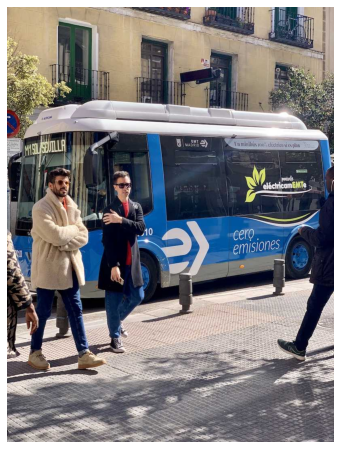

In [8]:
# Loading the Image
image = cv2.imread('./bus.jpg')
image_input = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Displaying the Image
plt.figure(figsize=(8, 8))
plt.axis('off')
plt.imshow(image_input)

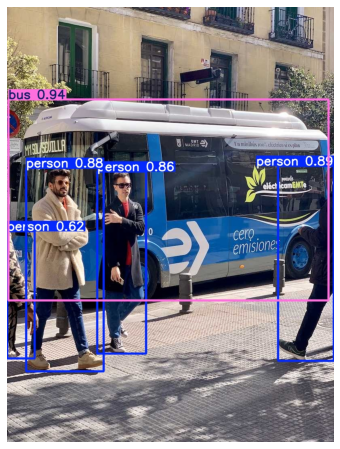

In [10]:
# Loading the output image.
image_yolo = cv2.imread('./runs/detect/predict/bus.jpg')
image_yolo = cv2.cvtColor(image_yolo, cv2.COLOR_BGR2RGB)

# Displaying the output image.
plt.figure(figsize=(8, 8))
plt.axis('off')
plt.imshow(image_yolo)

#### 3.3 Post Processing of Bounding Boxes


YOLO11 gives a output list containing different attributes like `masks` `boxes` `names` etc. to use as per your requirements.

 So, here we are calling the `boxes` method and storing it into an variable `box_yolo` , then we are convert the the `xyxy` co-ordinates tesor into a list. After this post-processing with the `boxes` object and specifically taking the `xyxy` boxes as a list, we store it in `box_list`.



In [11]:
box_yolo = results[0].boxes
print(box_yolo)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.], device='cuda:0')
conf: tensor([0.9402, 0.8881, 0.8783, 0.8558, 0.6221], device='cuda:0')
data: tensor([[3.8617e+00, 2.2936e+02, 7.9621e+02, 7.2840e+02, 9.4021e-01, 5.0000e+00],
        [6.7103e+02, 3.9485e+02, 8.0981e+02, 8.7872e+02, 8.8814e-01, 0.0000e+00],
        [4.7416e+01, 3.9957e+02, 2.3931e+02, 9.0421e+02, 8.7829e-01, 0.0000e+00],
        [2.2306e+02, 4.0868e+02, 3.4447e+02, 8.6044e+02, 8.5582e-01, 0.0000e+00],
        [2.1520e-02, 5.5607e+02, 6.8858e+01, 8.7236e+02, 6.2214e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[400.0356, 478.8844, 792.3480, 499.0405],
        [740.4185, 636.7820, 138.7823, 483.8692],
        [143.3624, 651.8884, 191.8924, 504.6364],
        [283.7633, 634.5602, 121.4086, 451.7562],
        [ 34.4395, 714.2142,  68.8361, 316.2981]], device='cuda:0')
xywhn: tensor([[0.4939, 0.4434, 0.97

In [12]:
# Extarcting the bounding box from results output.
box_yolo = results[0].boxes
box = box_yolo.xyxy.to(torch.int32)
# Converting the texnsor to a list for sam input.
box_list = box.cpu().tolist()
print(box_list)

[[3, 229, 796, 728], [671, 394, 809, 878], [47, 399, 239, 904], [223, 408, 344, 860], [0, 556, 68, 872]]


#### 3.4 SAM2 model loading and Inference

Ultralytics also provides pre-trained models like SAM2, Mobile SAM etc. in their library to make it easy for us. We can just import **SAM** module from Ultralytics like **YOLO**

**SAM2** takes bounding box input as **(x1,y1)(x2,y2)** format for inference.
We simply pass the inputs parameters like source image, bounding boxes (we got from YOLO11) and other optional arguments as well to run the inference.

In [13]:
# Load the model.
model = SAM('sam2.1_b.pt')

# Display model information (optional).
model.info()

# Run inference with bboxes prompt.
sam_results = model('./bus.jpg', bboxes=box_list, show=False, save=True)

Model summary: 436 layers, 80,850,178 parameters, 80,850,178 gradients

image 1/1 /home/ubuntu/opencv-dl-application-m4/bus.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 200.4ms
Speed: 4.0ms preprocess, 200.4ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /home/ubuntu/opencv-dl-application-m4/runs/segment/predict


#### 3.5 Visualization of Outputs

(-0.5, 809.5, 1079.5, -0.5)

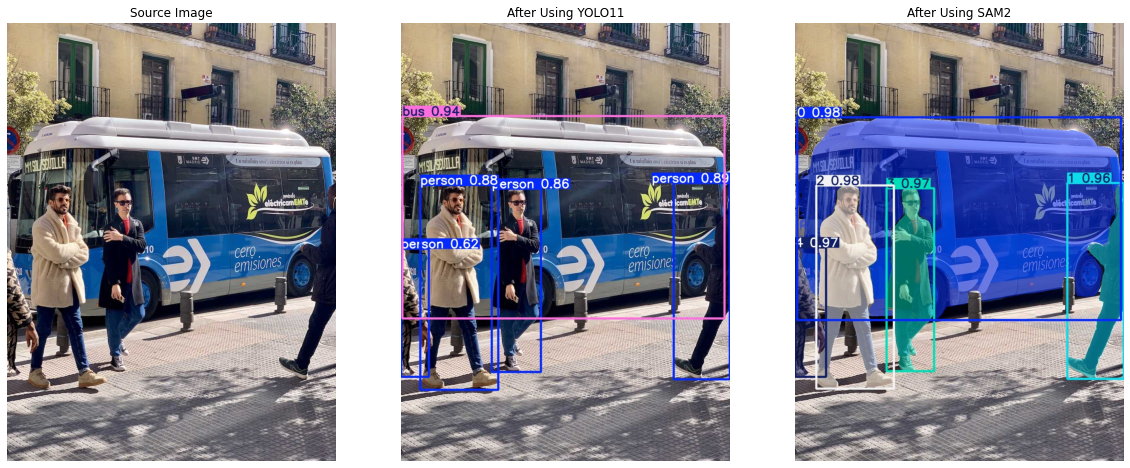

In [15]:
# Loading the output image.
image_sam = cv2.imread('./runs/segment/predict/bus.jpg')
image_sam = cv2.cvtColor(image_sam, cv2.COLOR_BGR2RGB)

plt.figure(figsize = [20,20])
plt.subplot(131); plt.imshow(image_input); plt.title('Source Image'); plt.axis('off')
plt.subplot(132); plt.imshow(image_yolo); plt.title('After Using YOLO11'); plt.axis('off')
plt.subplot(133); plt.imshow(image_sam); plt.title('After Using SAM2'); plt.axis('off')

## 4 Using **SAM2** Official Repository

#### 4.1 Imports

In [16]:
# Installing SAM2 and required packages
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib -q
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git' -q
!{sys.executable} -m pip install ultralytics -q

# Downloading the model.
!mkdir -p ../checkpoints/
!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

PyTorch version: 2.7.0
Torchvision version: 0.22.0
CUDA is available: True
--2026-06-19 13:22:47--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.74.36, 13.249.74.24, 13.249.74.50, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.74.36|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184416285 (176M) [application/vnd.snesdev-page-table]
Saving to: ‘../checkpoints/sam2.1_hiera_small.pt’

sam2.1_hiera_small. 100%[===================>] 175.87M   242MB/s    in 0.7s    

2026-06-19 13:22:48 (242 MB/s) - ‘../checkpoints/sam2.1_hiera_small.pt’ saved [184416285/184416285]



In [17]:
# Importing all the libraries.
import os
import cv2
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

##### Select the Device

In [18]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


##### Visulazing the Input Image

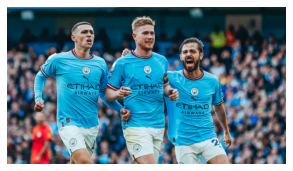

In [19]:
# Loading the Image.
image = cv2.imread('./football.jpg')
image_input = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(image_input)

#### 4.2 Loading the YOLO

Here we are doing the same processing step before pass the b-boxes to SAM2 like we did in previous section for Ultralytics.

Note - you can directly call the `results` varible from **3.2** section and skip this part, here we have done the same step for better understanding.

In [24]:
# Loading the model.
model = YOLO('yolo11n.pt')

# Running the inference.
results = model(source="./football.jpg", show=False, conf=0.5, save=True, classes=(0,5))

# Extracting the bounding boxes.
boxes_yolo = results[0].boxes.xyxy
print(boxes_yolo)


image 1/1 /home/ubuntu/opencv-dl-application-m4/football.jpg: 384x640 4 persons, 7.5ms
Speed: 1.4ms preprocess, 7.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /home/ubuntu/opencv-dl-application-m4/runs/detect/predict-3
tensor([[1080.0000,  210.0000, 1548.0000, 1074.0000],
        [ 672.0000,   60.0000, 1176.0000, 1068.0000],
        [ 181.5000,   96.0000,  852.0000, 1068.0000],
        [ 156.0000,  726.0000,  321.0000, 1074.0000]], device='cuda:0')


Visulaziting the YOLO output Image

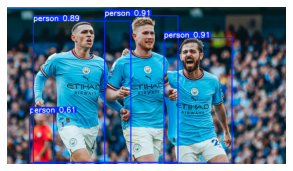

In [25]:
# Loading the Image.
image_yolo = cv2.imread('/home/ubuntu/opencv-dl-application-m4/runs/detect/predict-3/football.jpg')
image_yolo = cv2.cvtColor(image_yolo, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(image_yolo)

#### 4.3 Loading the SAM2 and Running Inference

We will load the Model now.

The SAM2 pretrained weights are available under Meta's [SAM2](https://github.com/facebookresearch/sam2) open source project.

We use SAM2.1, the improved SAM2 chechpoints relesed from meta. It has 4 varients:

* sam2.1_hiera_tiny.pt
* sam2.1_hiera_small.pt
* sam2.1_hiera_base_plus.pt
* sam2.1_hiera_large.pt

**We are using the sam2.1_hiera_small.pt model in this Notebook**

In [26]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# Load the model checkpoints
sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

# Build the model
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

# Set the model with input image
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(image)

* After we created the object `predictor` from `SAM2ImagePredictor` class, now we are all set to run the inference using the `predict` method.

* So, Now we will run the infrence and storing the outputs for post processing. Process the image to produce an image embedding by calling `SAM2ImagePredictor.set_image`. `SAM2ImagePredictor` remembers this embedding and will use it for subsequent mask prediction. For more details refer [here](https://colab.research.google.com/github/facebookresearch/sam2/blob/main/notebooks/image_predictor_example.ipynb).


In [27]:
# Running the inference.
masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=boxes_yolo,
    multimask_output=False,
)

With `multimask_output=True` (the default setting), SAM2 outputs 3 masks, where `scores` gives the model's own estimation of the quality of these masks. This setting is intended for ambiguous input prompts, and helps the model disambiguate different objects consistent with the prompt. When `False`, it will return a single mask. For ambiguous prompts such as a single point, it is recommended to use `multimask_output=True` even if only a single mask is desired; the best single mask can be chosen by picking the one with the highest score returned in `scores`. This will often result in a better mask.

#### 4.4 Post Processing of Outputs

Here we are defining functions for displaying the mask and the bounding boxes.

The `show_mask` function overlays a binary mask onto a given axis with color and opacity control, applying either a random color if `random_color=True` or a default RGBA color (semi-transparent blue). The mask is reshaped to add a color dimension and multiplied by this color to create the final overlay. If `borders=True`, OpenCV is used to detect and smooth the external contours of the mask, which are then drawn in white with a specified thickness for enhanced boundary clarity.

The `show_points` function displays labeled points on an axis, distinguishing between categories through color and marker styles: positive points (label=1) appear as green stars, and negative points (label=0) as red stars. Each point is marked with a white border for contrast, using a customizable `marker_size` parameter to control visibility and ensure clarity regardless of the image scale.

The `show_box` function draws a bounding box on the specified axis, designed to handle GPU tensors by transferring them to the CPU when necessary. The function extracts the top-left corner (`x0`, `y0`) and calculates width and height based on the box’s coordinates. It then draws a green, unfilled rectangle to outline the region, emphasizing the area of interest without obstructing the underlying content.

In [28]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    # Move box to CPU if it's a GPU tensor
    if box.is_cuda:
        box = box.cpu()
    x0, y0 = box[0].item(), box[1].item()
    w, h = box[2].item() - box[0].item(), box[3].item() - box[1].item()
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

#### 4.5 Visualization of Outputs

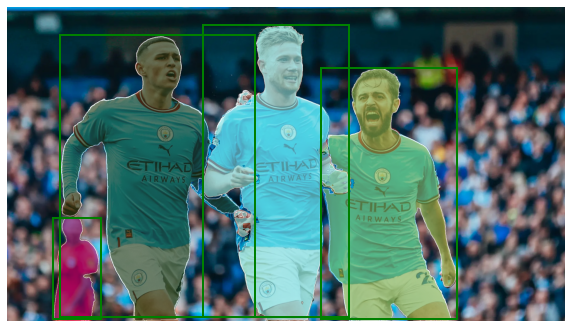

In [29]:
plt.figure(figsize=(10, 10))
plt.imshow(image[:,:,::-1])
for mask in masks:
    show_mask(mask.squeeze(0), plt.gca(), random_color=True)
for box in boxes_yolo:
    show_box(box, plt.gca())
plt.axis('off')
plt.savefig('output_image.png', bbox_inches='tight', pad_inches=0.0)
plt.show()

In [30]:
# Comparing the results
from google.colab.patches import cv2_imshow
image_sam = cv2.imread('output_image.png')
image_sam = cv2.cvtColor(image_sam, cv2.COLOR_BGR2RGB)

plt.figure(figsize = [20,20])
plt.subplot(131); plt.imshow(image_input); plt.title('Source Image'); plt.axis('off')
plt.subplot(132); plt.imshow(image_yolo); plt.title('After Using YOLO11'); plt.axis('off')
plt.subplot(133); plt.imshow(image_sam); plt.title('After Using SAM2'); plt.axis('off')

ModuleNotFoundError: No module named 'google.colab'

## 5 Conclusion

In conclusion, this project successfully implemented SAM2 image segmentation and integrated YOLO11 with SAM2. The notebook described how to automate the image segmentation process with the bounding box generation using YOLO11 and use those bounding box coordinates as an input to SAM2.